# Watch Calibration Experiment

The watch calibration experiment serves as an extremely basic example of how to record data, analyze it, and make your experiment completely reproducible for others far into the future. The concept of and code for this experiment is rather simple, and the focus is instead on best practices for archiving data, code, and the environment that runs the code.

## jupyter notebook

This jupyter notebook serves as a development environment

## imports and setup

In [1]:
# automatically reload watch_calibration python package in case we edit it
%load_ext autoreload
%autoreload 2
# enable the ipympl backend for interactive figures
%matplotlib widget

import copy
import os
import time 

import ipywidgets as widgets
import librosa
import numpy as np
import random
import scipy
from ipympl.backend_nbagg import Canvas
from matplotlib import pyplot as plt
from scipy import signal as sps
from scipy.io.wavfile import write

# globally remove ipympl headers
Canvas.header_visible.default_value = False

# import watch calibration experiment code
from watch_calibration import WatchCalibration

In [2]:
# set environment variables
RAW_DATA_PATH = os.environ["ARTS_RAW_DATA_PATH"]

In [3]:
# prevent race condition where plots aren't showing after "Restart Kernel and Run All Cells" is selected
time.sleep(.5)

# suppress warning about too many open figures
plt.rcParams.update({'figure.max_open_warning': 0})

In [4]:
# close all open plots to free up memory
plt.close('all')

## raw data collection/generation

In [5]:
# show all system audio inputs and outputs
WatchCalibration.query_devices()

In [6]:
# audio recording parameters

# use system defaults; can change to int values above corresponding to specific interfaces
INPUT_DEVICE = None
OUTPUT_DEVICE = None

fs = 44100  # Sample rate

audio_files = [
    f"../{RAW_DATA_PATH}/data_W241130_W241130.wav", 
    f"../{RAW_DATA_PATH}/data_W250227_W250227.wav", 
    f"../{RAW_DATA_PATH}/data5m_W250227_W250227.wav"
]
audio_file = audio_files[1]

In [7]:
# instantiate experiment code class
wc = WatchCalibration(fs, audio_file)

In [8]:
def recreate_dataset(generate=True, duration=60):
    """Create new data set from scratch.
        generate
        duration
    """

    wc.save_audio_to_file(duration, input_device=INPUT_DEVICE, generate=generate)

# Uncomment the next line to record duration seconds of audio 
# recreate_dataset(generate=False, duration=5*60)

# play audio file
# Uncomment the next line to play the selected audio file
# wc.play_audio(audio_file, output_device=OUTPUT_DEVICE)

## data visualization

In [9]:
def load_audio(audio_file, duration_sec=None, last=False):
    # load audio
    watch_audio, _ = wc.load_audio(audio_file)    
    if duration_sec:
        if last:
            # return only last duration_sec of audio
            watch_audio = watch_audio[:wc.fs*duration_sec]
        else:
            # return only first duration_sec of audio
            watch_audio = watch_audio[:wc.fs*duration_sec]
    return watch_audio


watch_audio = load_audio(audio_file)

### plot time and frequency signal

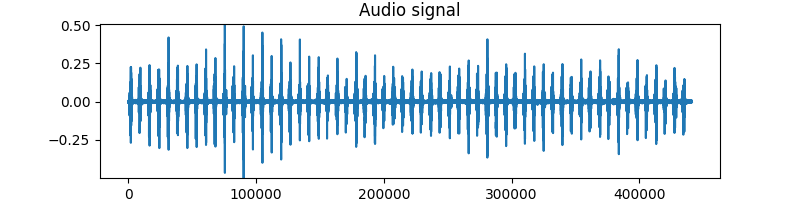

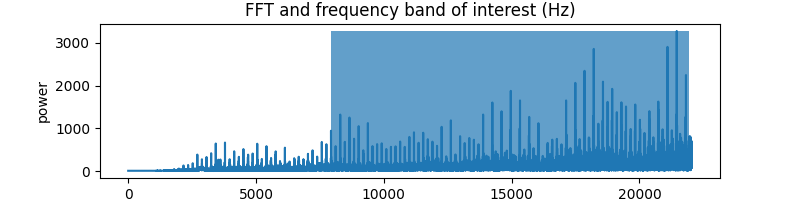

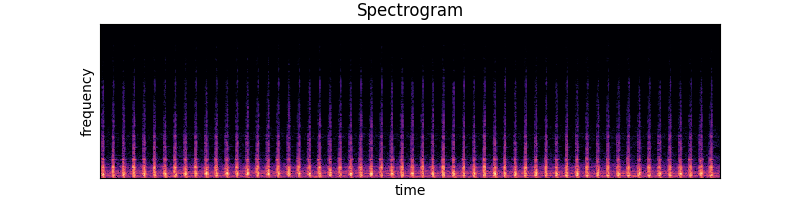

In [10]:
PLT_SECS = 10 

# plot last PLT_SECS seconds of time signal and spectrogram; plot full fft 
wc.plot_audio(watch_audio, plt_secs=PLT_SECS)

## derivative data

In [11]:
deriv_data = wc.create_deriv_from_raw(filter=False)
# deriv_data = wc.create_deriv_from_raw(watch_audio)
wc.save_deriv_data()

## Analysis

### Background

The goal of this analysis is to determine the clock drift of the watch measured in the supplied audio recording. By clock drift here, we mean the amount per unit time that recorded watch ticks will differ from those from an ideal clock with an invariant tick frequency. In order to calculate clock drift, we first need to precisely and accurately determine the time at which watch ticks occur.

There a number of ways to pick out clock ticks from an audio waveform, but the basic idea is to pinpoint where all the clock ticks happen by looking at the waveform and where it peaks in amplitude, calculate the average time between clicks in the recording, and compare it to the ideal tick period. This assumes that the clock ticks are ideally tuned to a specific frequency (in this case, 6 Hz) which comprise a 1 Hz rythym defining a second.

### Manual method

A fairly manual method to achieve a rough estimate of clock drift using Audacity can be found [here](https://www.instructables.com/Calibrate-a-Mechanical-Watch-Using-Sound-Waves/) and includes amplification of the signal, noise reduction, the generation of an ideal click track, alignment of the intial peaks, and measurement of the timing difference between final peaks. Once the difference is measured, the clock drift is simply the difference divided by the unit time over which the drift is measured. This method requires visually aligning signal peaks and realistically can measure drift on the order of a few milliseconds per recording at best.

### Automated method

To automate this, we make use of the `scipy.signal.find_peaks` and `numpy.correlate` functions. 

This method is implemeted by the `WatchCalibration.perform_analysis` method which calls ...

```
find_peaks
block out sets
make sure there is a window for each one
cross correlation
hilbert transform
re run across entire set
do stats

fit template to peak (template matching)
convex hull -> hilbert transform
run a cross correlation
```


### find_peaks



FloatSlider(value=0.0, max=57.666666666666664)

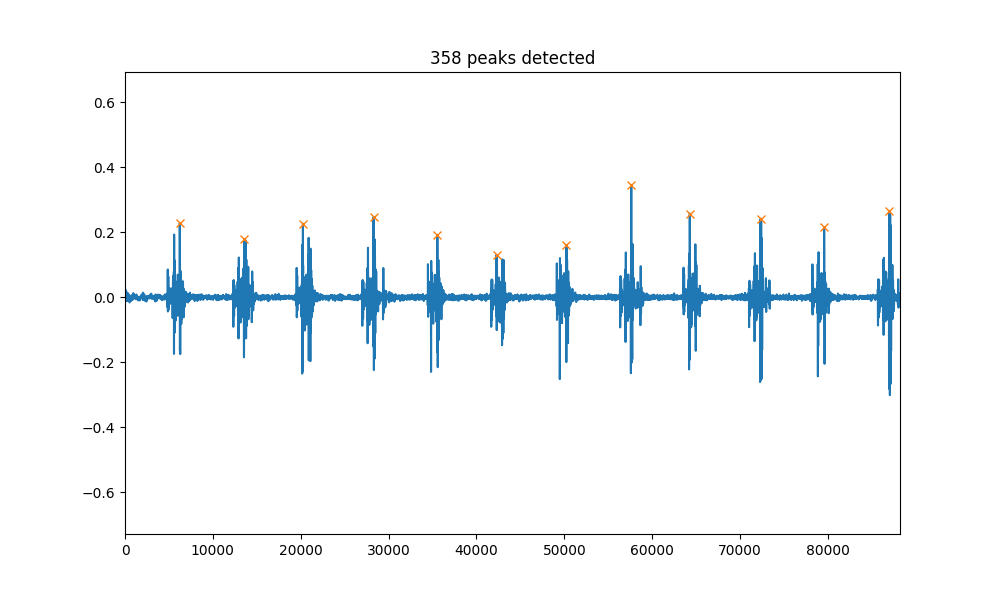

In [12]:
FREQ_GUESS = 6.
PEAK_PROMINENCE = 0.002


distance = int(wc.fs/FREQ_GUESS*.9)
win_size = int(wc.fs/FREQ_GUESS)
comp_audio = wc.trim_audio(watch_audio)
    
def plot_peaks(x, peaks):
    if len(x) > wc.fs * 2:
        fig, ax = plt.subplots(figsize=(10,6))
        ax.plot(x)
        ax.plot(peaks, x[peaks], "x")
        ax.set_xlim(0,wc.fs*2)
        ax.set_title(f"{len(peaks)} peaks detected")
        
        slider = widgets.FloatSlider(value=0, max=len(x)/wc.fs-2, step=0.1, continuous_update=True)
        def update(change):
            ax.set_xlim(change.new*wc.fs, (change.new+2)*wc.fs)
            fig.canvas.draw_idle() 
        slider.observe(update, names='value')
    
        display(slider)
    

# peaks = sps.find_peaks(comp_audio, distance=distance, prominence=PEAK_PROMINENCE, wlen=distance)[0]
# print(peaks)
# print(wc.peaks)
plot_peaks(comp_audio, wc.peaks)

### cross-correlation

Cross-correlation gives us a way to measure similarity between two signals. For digital signals, the dot product between the two signals is calculated repeatedly as the signals are shifted along the x-axis with respect to each other. The index of the maximum value of the cross-correlation result indicates by how many samples the signals should be shifted in order to be most aligned. 

We use this method to determine how much to shift the tick period between subsequent ticks as initially determined by the `find_peaks` method.

Below is a demonstration of how tick windows are aligned:

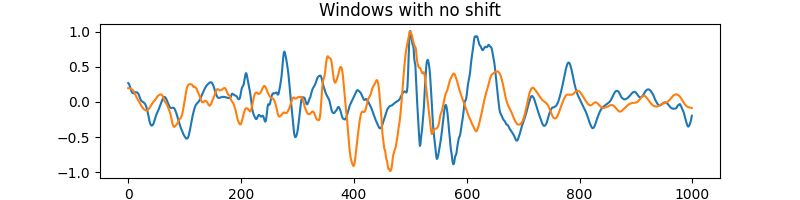

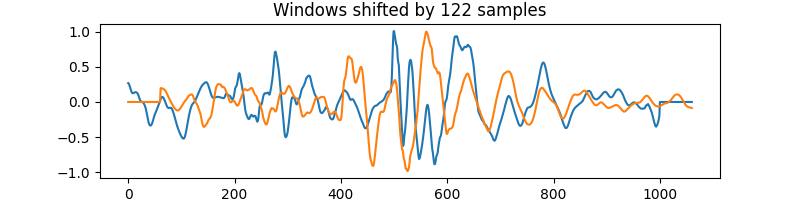

In [13]:
# pick two random tick windows
win1 = random.choice(wc.audio_wins)
win2 = random.choice(wc.audio_wins)

# normalize the windows
win1 = wc._normalize(win1)
win2 = wc._normalize(win2)

# determine the shift between the windows
shift = wc._corr_wins(win1, win2)

# plot the original and shifted windows 
wc.plot_wins(win1, win2, title="Windows with no shift")
wc.plot_wins(win1, win2, shift_amt=shift, title=f"Windows shifted by {shift} samples")

### filtering

Filtering the signal before running `find_peaks` or `correlate` can remove noise from the audio recording and make for a more accurate comparison of the underlying clock tick.

Here we filter the signal using a Butterworth band-pass filter from 6000 Hz to 8500 Hz. 

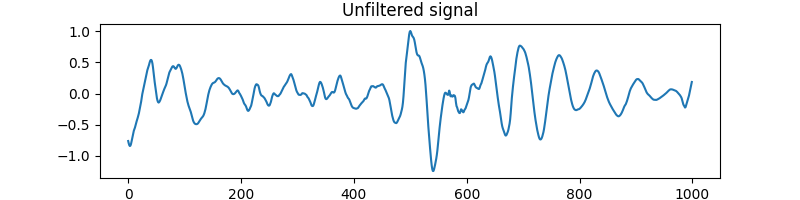

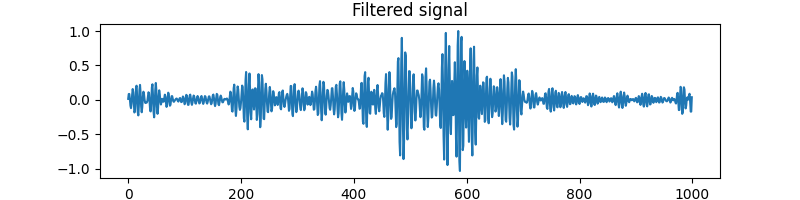

In [14]:
# remove first and last ticks from the signal
comp_audio = wc.trim_audio(watch_audio)

# filter out frequencies not in the specified band
freq_band = (6000, 8500)
filtered_audio = wc.filter_audio(comp_audio, freq_band=freq_band)

# pick random window to display
win_num = random.randrange(0, len(wc.audio_wins))
win = wc._normalize(wc.audio_wins[win_num])
peak = wc.peaks[win_num]
filt_win = wc._normalize(filtered_audio[peak-wc.window_len//2:peak+wc.window_len//2])

# plot window and filtered version
wc.plot_wins(win, None, title="Unfiltered signal")
wc.plot_wins(filt_win, None, title="Filtered signal")

### envelope

We can also try to align tick windows based off their envelopes. The signal envelope is computed with `scipy.signal.envelope` and cross-correlation performed on the result.

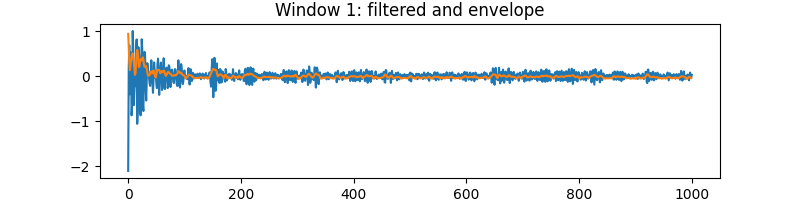

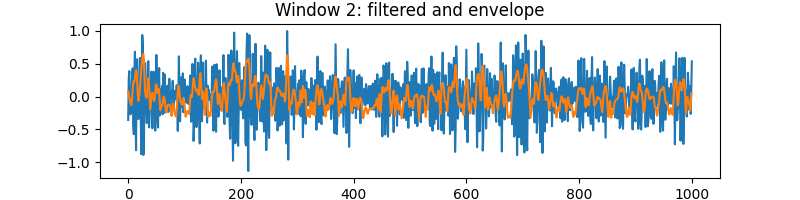

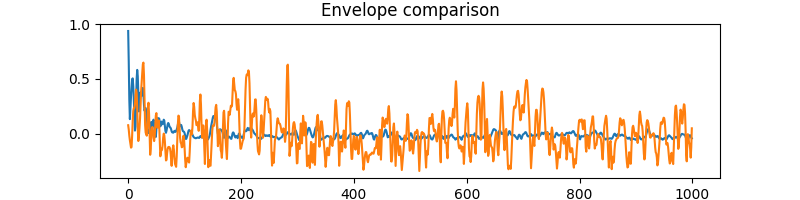

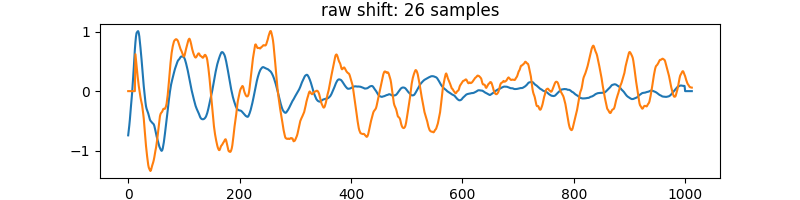

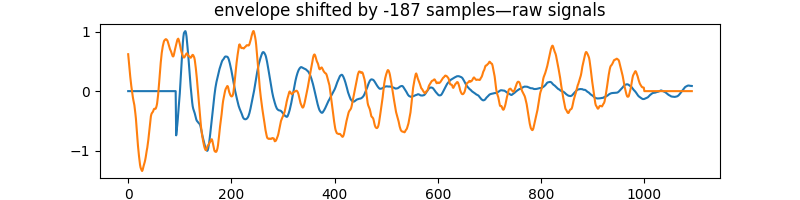

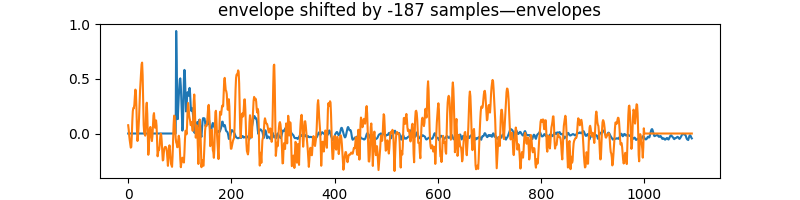

In [15]:
# show envelope example

comp_audio = watch_audio[wc.window_len:-wc.window_len]

filtered_audio, envelope = wc.calculate_envelope(comp_audio)

# pick random windows to display
win_num = random.randrange(0, len(wc.audio_wins))
peak = wc.peaks[win_num]
win1 = wc._normalize(comp_audio[peak-wc.window_len//2:peak+wc.window_len//2])
win1_filt = wc._normalize(filtered_audio[peak-wc.window_len//2:peak+wc.window_len//2 + 1])
env1 = wc._normalize(envelope[peak-wc.window_len//2:peak+wc.window_len//2])

win_num = random.randrange(0, len(wc.audio_wins))
peak = wc.peaks[win_num]
win2 = wc._normalize(comp_audio[peak-wc.window_len//2:peak+wc.window_len//2])
win2_filt = wc._normalize(filtered_audio[peak-wc.window_len//2:peak+wc.window_len//2 + 1])
env2 = wc._normalize(envelope[peak-wc.window_len//2:peak+wc.window_len//2])

wc.plot_wins(win1_filt, env1, title="Window 1: filtered and envelope")
wc.plot_wins(win2_filt, env2, title="Window 2: filtered and envelope")

wc.plot_wins(env1, env2, title="Envelope comparison")

shift_amt = wc._corr_wins(win1, win2)
wc.plot_wins(win1, win2, shift_amt, title=f"raw shift: {shift_amt} samples")
env_shift_amt = wc._corr_wins(env1, env2)
wc.plot_wins(win1, win2, env_shift_amt, title=f"envelope shifted by {env_shift_amt} samples—raw signals")
wc.plot_wins(env1, env2, env_shift_amt, title=f"envelope shifted by {env_shift_amt} samples—envelopes")

### comparison

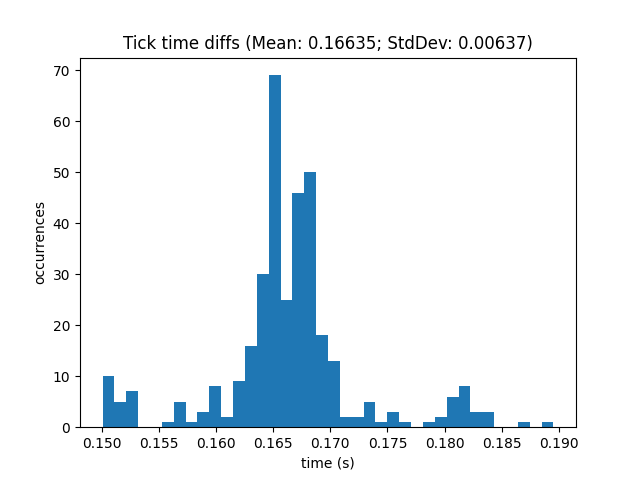

In [16]:
fig_wins = wc.view_correlations()
if fig_wins: display(fig_wins) 

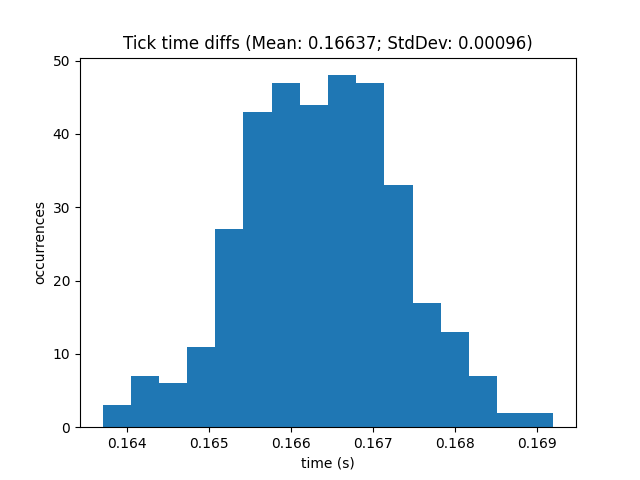

In [17]:
# cross-correlation shift
fig_wins = wc.view_correlations(filter=True)
if fig_wins: display(fig_wins) 

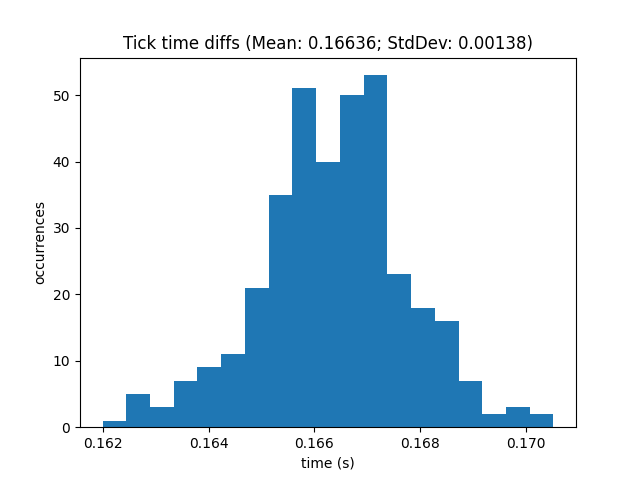

In [18]:
# cross-correlation shift
fig_wins = wc.view_correlations(filter=True, shift=True)
if fig_wins: display(fig_wins) 

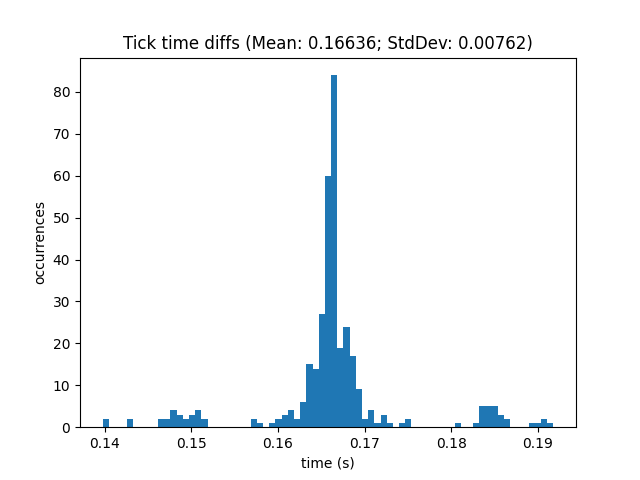

In [19]:
# cross-correlation shift on envelope
fig_wins = wc.view_correlations(shift=True, envelope=True)
if fig_wins: display(fig_wins)

### Calculating drift

Now that we have a sense 

#### Best possible drift

fs = 44100; 1/fs resolution or ~23us. This means that in a 1 minute recording, the best we can do is tell if the drift from the first onset to the last onset is within 23us (12.5us error on each onset). This is a best case of 1.4 ms/h, 33ms per day or ~1s per month

In [20]:
wc.perform_analysis(filter=True, envelope=True, shift=True)

[-0.05390248 -0.06138325 -0.0542415  ... -0.00146852 -0.00151055
 -0.00155526]
2646000
[   6241   13542   20906   28244   35555   42904   50219   57572   64917
   72327   79576   87003   94256  101677  108935  116289  123631  130982
  138300  145646  152960  160371  167649  175002  182326  189693  197004
  204385  211675  218967  226343  233629  241007  248342  255657  263024
  270330  277665  285023  292410  299674  307023  314357  321717  329036
  336376  343726  351138  358394  365745  373057  380450  387736  395090
  402417  409769  417095  424404  431760  439045  446430  453715  461096
  468426  475738  483106  490409  497741  505099  512426  519753  527152
  534427  541829  549111  556457  563793  571142  578466  585807  593126
  600508  607804  615210  622490  629830  637166  644480  651837  659130
  666504  673792  681172  688502  695816  703155  710498  717857  725184
  732595  739839  747294  754518  761957  769197  776574  783885  791263
  798561  805925  813230  820626  827

np.float64(-0.0017989843824852692)

### Calculate drift across all recordings and parameters

In [21]:


for f in audio_files:
    w = WatchCalibration(audio_file=f)
    drift = w.perform_analysis(filter=True, envelope=True, shift=True, output=False)
    print(drift)

[0.00066897 0.00104236 0.00105117 ... 0.00012867 0.00014663 0.00010484]
2646000
[   3437   10708   18123   25423   32899   40139   47525   54821   62253
   69495   76918   84200   91642   98887  106361  113569  121054  128274
  135756  143003  150124  157369  165138  172157  179826  187085  194527
  201798  209215  216207  223922  231187  238615  245913  253303  260616
  268010  275318  282747  290006  297410  304810  312145  319411  326840
  334075  341554  348975  356248  363312  370941  378173  385633  392651
  400327  407604  415014  422326  429698  437048  444470  451737  459105
  466477  473815  481112  488505  495813  503252  510533  517920  524883
  532644  539905  547394  554267  562053  569260  576745  584082  591440
  598719  606132  613365  620799  628071  635495  642936  650310  657804
  665111  672384  679607  687002  694311  701609  709002  715987  723726
  731017  738403  745489  753109  760398  767810  775108  782554  789758
  797243  804284  811927  819008  826629  83

IndexError: index -1 is out of bounds for axis 0 with size 0



### Generate figures for paper

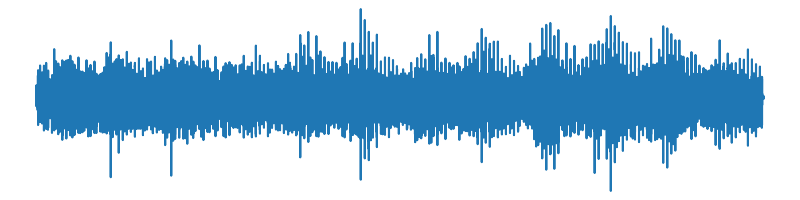

In [22]:
wc.generate_figures(watch_audio)